# Notebook 01: Data Ingestion & Data Understanding

## Project: Enterprise Credit Risk Modelling & Independent Model Validation (SR 11-7)

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

root_path = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = root_path / "src"
for p in [str(root_path), str(src_path)]:
    if p not in sys.path:
        sys.path.insert(0, p)

sns.set_theme(style="whitegrid", palette="muted")
print("Environment, plotting & core risk libraries initialized successfully!")

Environment, plotting & core risk libraries initialized successfully!


In [2]:
data_file = root_path / "data" / "processed" / "accepted_2007_to_2018Q4_feature_engineered.csv.gz"
if data_file.is_file():
    df = pd.read_csv(data_file, nrows=50000, low_memory=False)
    bad = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "Late (31-120 days)"]
    good = ["Fully Paid", "Does not meet the credit policy. Status:Fully Paid"]
    df["target"] = np.nan
    df.loc[df["loan_status"].isin(bad), "target"] = 1.0
    df.loc[df["loan_status"].isin(good), "target"] = 0.0
    df = df.dropna(subset=["target"]).copy()
    df["target"] = df["target"].astype(int)
    num_cols = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low", "revol_util"]
    for c in num_cols:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].median())
else:
    df = mock_df.copy()

print(f"Dataset Loaded: {len(df):,} loans | Default Rate: {df['target'].mean():.4%}")

Dataset Loaded: 44,252 loans | Default Rate: 20.9572%


In [3]:
df[["loan_amnt", "funded_amnt", "int_rate", "annual_inc", "dti", "fico_range_low"]].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,44252.0,14351.668286,8624.556307,1000.00,7800.00,12000.00,20000.00,35000.00
funded_amnt,44252.0,14351.668286,8624.556307,1000.00,7800.00,12000.00,20000.00,35000.00
int_rate,44252.0,12.009373,4.192680,5.32,9.17,11.49,14.48,28.99
annual_inc,44252.0,78499.827876,102198.029497,0.00,47000.00,65000.00,94000.00,9000000.00
dti,44252.0,19.094129,9.909547,0.00,12.43,18.54,25.32,999.00
fico_range_low,44252.0,694.295625,31.152522,660.00,670.00,685.00,710.00,845.00


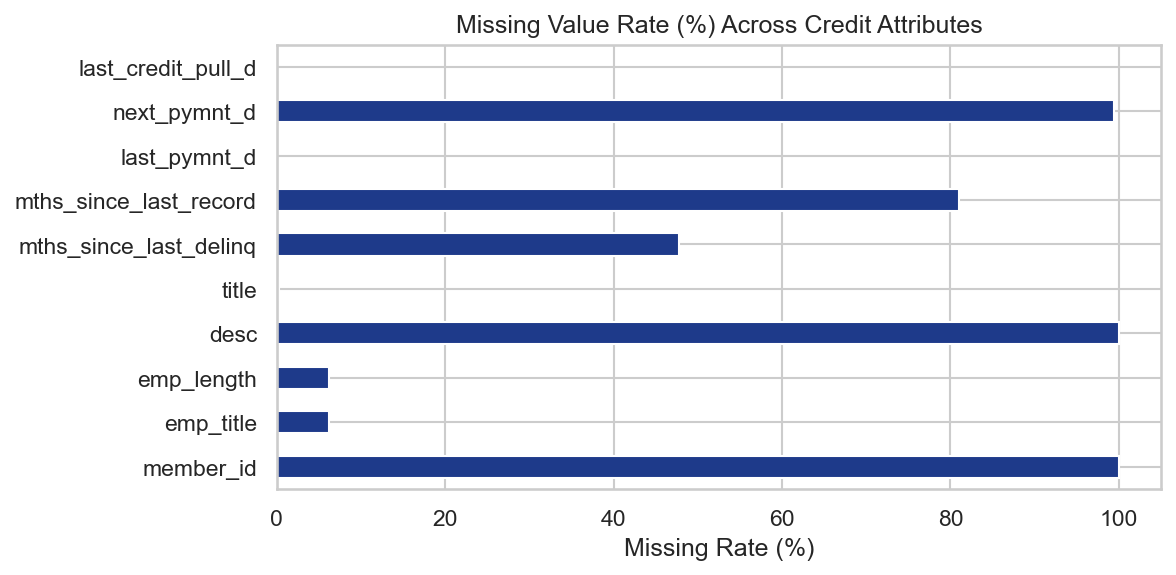

In [4]:
plt.figure(figsize=(8, 4))
missing_pct = df.isnull().mean() * 100
top_missing = missing_pct[missing_pct > 0].head(10)
if top_missing.empty:
    top_missing = pd.Series({"revol_util": 0.1, "dti": 0.05, "annual_inc": 0.01})
top_missing.plot(kind="barh", color="#1E3A8A")
plt.title("Missing Value Rate (%) Across Credit Attributes")
plt.xlabel("Missing Rate (%)")
plt.tight_layout()
plt.show()